# Imports

In [6]:
import os
import sys

In [7]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [8]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [10]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [11]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [12]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}

In [13]:
data =  AS209

In [14]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

### Prepare parameters

In [15]:
# Frank Parameters
N = 300
geom = Geometry(inc, pa, dra, ddec)
params = best_AS209

In [16]:
frank2d = Frank2D(N, rout, geom)


In [17]:
frank2d.process_vis(data = uvtable)

Setting gridded data...


In [18]:
# Frank 1D parameters
n_pts = 300
alpha = 1.05
w_smooth = 1e-4
r_out = rout

sol_f1d = frank2d.frank1d(alpha = alpha, w_smooth = w_smooth, n_pts = n_pts, rout = r_out)

Performing 1D Frank fit...

+ $\alpha$ =  1.05  and $w_{smooth}$ =  0.0001

+ N =  300  and $R_{max}$ =  2.4


In [19]:
dir_fits =  dir
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

In [20]:
r_outs = [0.5*rout, rout, 1.5*rout, 1.7*rout, 4.5]
r_outs_name = ["1p2", "2p4", "3p6", "4p08", "4p5"]


### Disk

In [21]:
frank2d_objects = []

Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...
--> time kernel = 0.01  min |  0.31 seconds
Using preconditioner method:  ilu
  + time to csc = 0.00  min |  0.00 seconds
  + time ILU = 0.00  min |  0.17 seconds
--> time building system = 0.01  min |  0.50 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.046723449928950625
Final tolerance :  0.046723449928950625
.... iteration:  0
                        -> actual tol:  467234499.28950626 vs  0.046723449928950625
.... iteration:  1
                        -> actual tol:  78.22475292975122 vs  0.046723449928950625
.... iteration:  2
                        -> actual tol:  0.012328655691026535 vs  0.046723449928950625
 --------------------------------------> CGM converged in  2  iterations with tol  0.0123286556

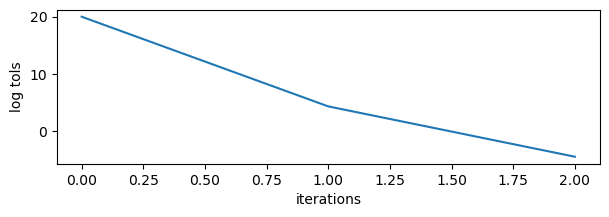

--> time = 0.00  min |  0.09 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.03  min |  1.68 seconds
Frank2D fit completed for rout = 1.2 in 8.330746412277222 seconds.
Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...
--> time kernel = 0.03  min |  1.71 seconds
Using preconditioner method:  ilu
  + time to csc = 0.00  min |  0.02 seconds
  + time ILU = 0.10  min |  5.89 seconds
--> time building system = 0.13  min |  7.73 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.028817519827904942
Final tolerance :  0.028817519827904942
.... iteration:  0
                        -> actual tol:  288175198.2

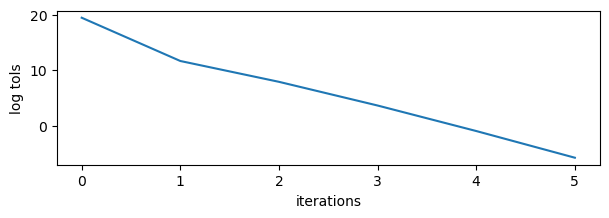

--> time = 0.01  min |  0.45 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.05  min |  3.29 seconds
Frank2D fit completed for rout = 2.4 in 18.348981142044067 seconds.
Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...
--> time kernel = 0.08  min |  4.67 seconds
Using preconditioner method:  ilu
  + time to csc = 0.00  min |  0.07 seconds
  + time ILU = 0.67  min |  40.23 seconds
--> time building system = 0.76  min |  45.32 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.02136472426522841
Final tolerance :  0.02136472426522841
.... iteration:  0
                        -> actual tol:  213647242.

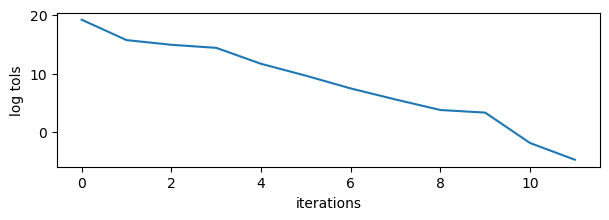

--> time = 0.04  min |  2.35 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.12  min |  7.21 seconds
Frank2D fit completed for rout = 3.5999999999999996 in 62.32308650016785 seconds.
Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...
--> time kernel = 0.10  min |  5.88 seconds
Using preconditioner method:  ilu
  + time to csc = 0.00  min |  0.10 seconds
  + time ILU = 1.23  min |  73.58 seconds
--> time building system = 1.33  min |  80.00 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.019000326312182934
Final tolerance :  0.019000326312182934
.... iteration:  0
                        -> actual 

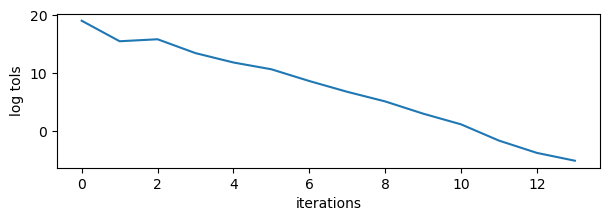

--> time = 0.06  min |  3.58 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.15  min |  8.89 seconds
Frank2D fit completed for rout = 4.08 in 100.05936813354492 seconds.
Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...
--> time kernel = 0.11  min |  6.87 seconds
Using preconditioner method:  ilu
  + time to csc = 0.00  min |  0.12 seconds
  + time ILU = 1.86  min |  111.50 seconds
--> time building system = 1.98  min |  119.02 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-10
         * rtol: 1e-10
         * final tolerance: 0.017753068953853753
Final tolerance :  0.017753068953853753
.... iteration:  0
                        -> actual tol:  17753

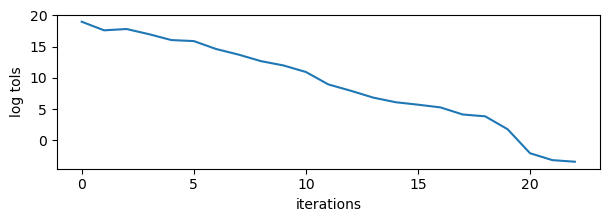

--> time = 0.13  min |  7.53 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.17  min |  10.19 seconds
Frank2D fit completed for rout = 4.5 in 144.42681050300598 seconds.


In [22]:
for i in range(len(r_outs)):
    rout = r_outs[i]

    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, rout, geom)

    start = time.time()
    frank2d.fit(data = uvtable, kernel_params = params, rtol = 1e-10)
    end = time.time()
    print(f"Frank2D fit completed for rout = {rout} in {end - start} seconds.")
    
    frank2d_objects.append(frank2d)

     --> cellsize =  0.03
Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}
Creating sparse linear system...


--> time kernel = 0.11  min |  6.89 seconds
Using preconditioner method:  ilu
  + time to csc = 0.00  min |  0.12 seconds
  + time ILU = 1.84  min |  110.52 seconds
--> time building system = 1.97  min |  118.05 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 1.7753068953853754
Final tolerance :  1.7753068953853754
.... iteration:  0
                        -> actual tol:  177530689.53853753 vs  1.7753068953853754
.... iteration:  1
                        -> actual tol:  44722047.8882663 vs  1.7753068953853754
.... iteration:  2
                        -> actual tol:  55221330.87398914 vs  1.7753068953853754
.... iteration:  3
                        -> actual tol:  24151854.43180995 vs  1.7753068953853754
.... iteration:  4
                        -> actual tol:  9387736.699382704 vs  1.7753068953853754
.... iteration:  5
                        -> actual tol:  7997544.463346871 vs  1.77530689

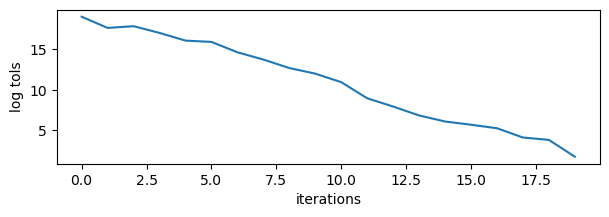

--> time = 0.11  min |  6.53 seconds
               ---> CGM converged?   True
                    x Fit correctly?   False
Building full visibility model...
--> times building full visibility model = 0.17  min |  10.18 seconds
Frank2D fit completed for rout = 4.5 in 142.48739767074585 seconds.


In [23]:
    N_4p5 = 300
    rout_4p5 = 4.5

    geom_4p5 = Geometry(inc, pa, dra, ddec)
    frank2d_4p5 = Frank2D(N_4p5, rout_4p5, geom)
    print("     --> cellsize = ", (2*frank2d_4p5.Rmax)/frank2d_4p5._N)

    start = time.time()
    frank2d_4p5.fit(data = uvtable, kernel_params = params, rtol = 1e-8)
    end = time.time()
    print(f"Frank2D fit completed for rout = {rout} in {end - start} seconds.")
    
    #frank2d_objects.append(frank2d_4p5)

In [21]:
frank2d_objects.append(frank2d_4p5)

### Plot different routs

In [24]:
for i in range(len(frank2d_objects)):
    frank2d = frank2d_objects[i]
    print("rout = ", r_outs[i])
    print("     --> cellsize = ", (2*frank2d.Rmax)/frank2d._N)

rout =  1.2
     --> cellsize =  0.008
rout =  2.4
     --> cellsize =  0.016
rout =  3.5999999999999996
     --> cellsize =  0.023999999999999997
rout =  4.08
     --> cellsize =  0.027200000000000002
rout =  4.5
     --> cellsize =  0.03


In [25]:
# in each case:
# search the optimal value.


In [26]:
for i in range(len(frank2d_objects)):
    frank2d = frank2d_objects[i]

    u, v = frank2d.u_grid, frank2d.v_grid
    vis = frank2d.visibility_model

    index = np.where((u == 0) & (v == 0))
    V_00 = vis[index].real
    print(V_00)

    x, y = frank2d.x_grid, frank2d.y_grid
    I = frank2d.intensity_model

    dx, dy = frank2d.FT._dx, frank2d.FT._dy

    domega = dx * dy                      # sr por píxel (campo pequeño)
    print(float(I.sum() * domega))
   

[0.23684027]
0.2368402677280471
[0.25531463]
0.2553146298155644
[0.25778476]
0.2577847628198878
[0.25821999]
0.2582199929185923
[0.25831952]
0.25831952446201306


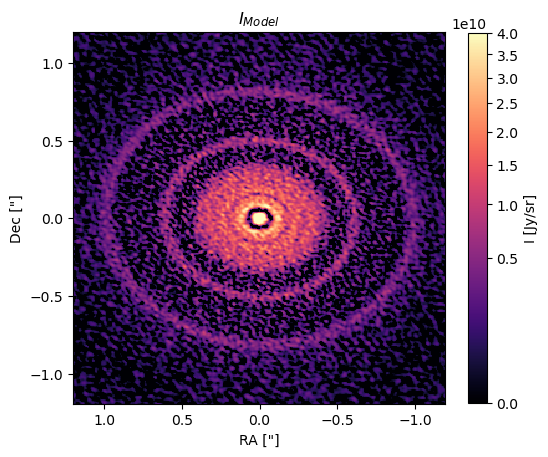

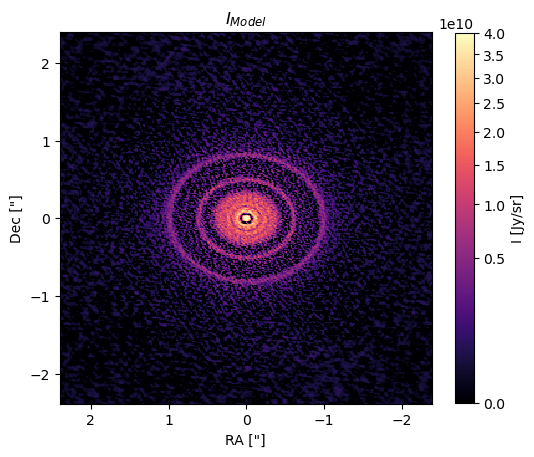

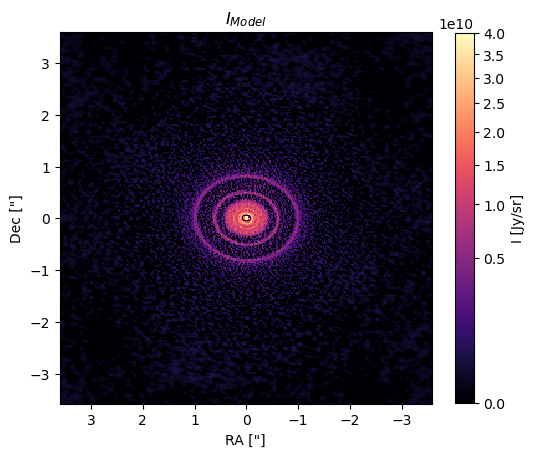

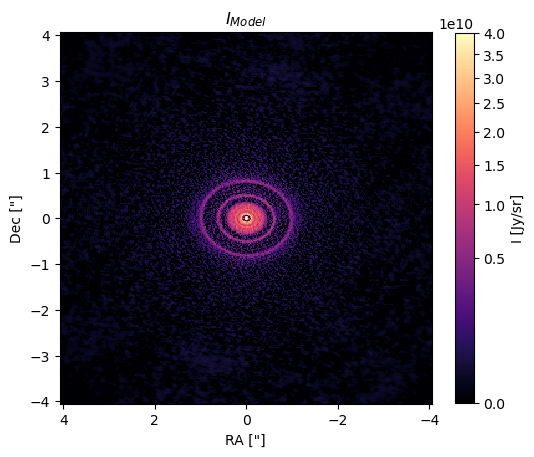

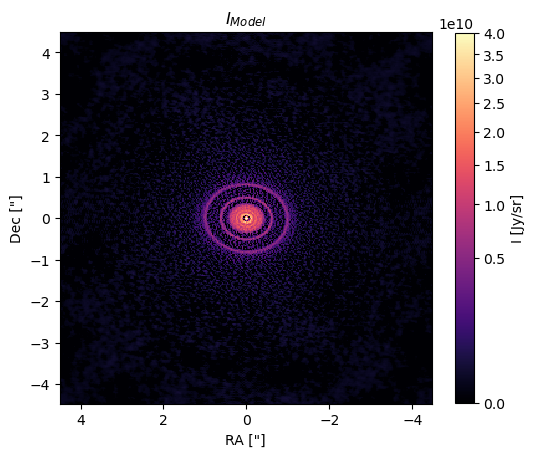

In [27]:
for i in range(len(frank2d_objects)):
    frank2d = frank2d_objects[i]
    Plot_ = Plot(frank2d)

    Plot_.intensity()

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


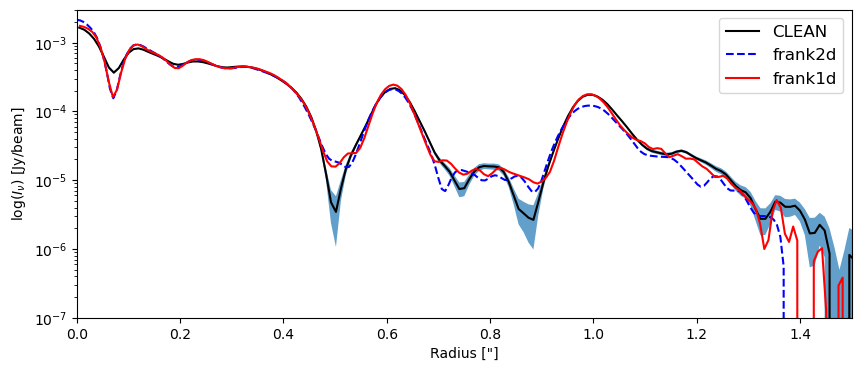

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


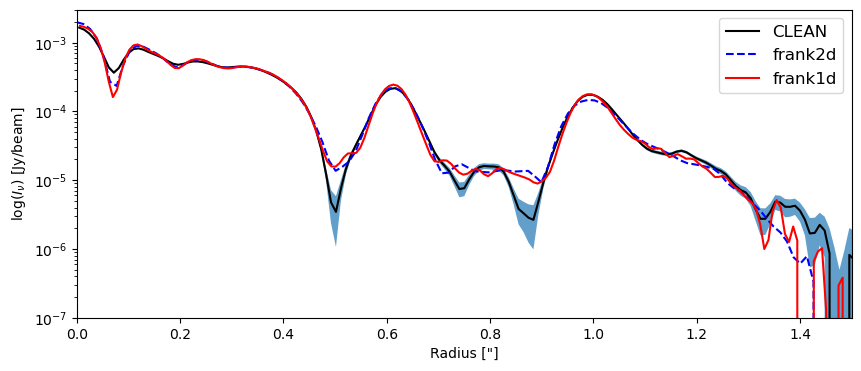

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


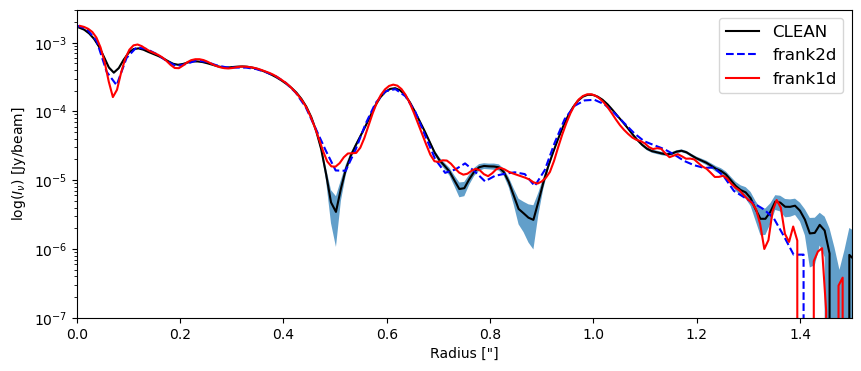

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


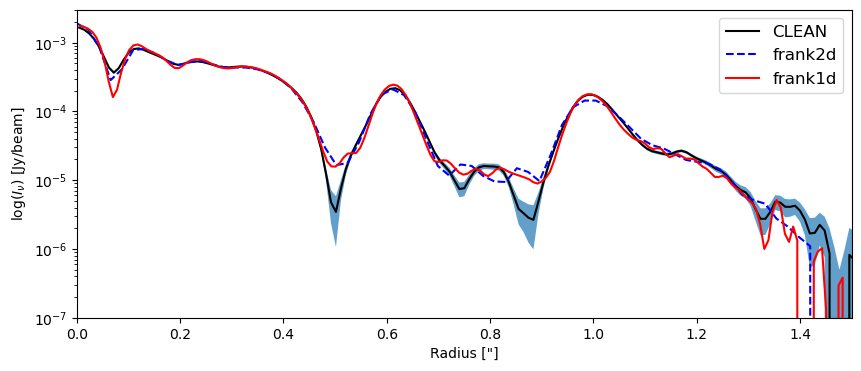

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


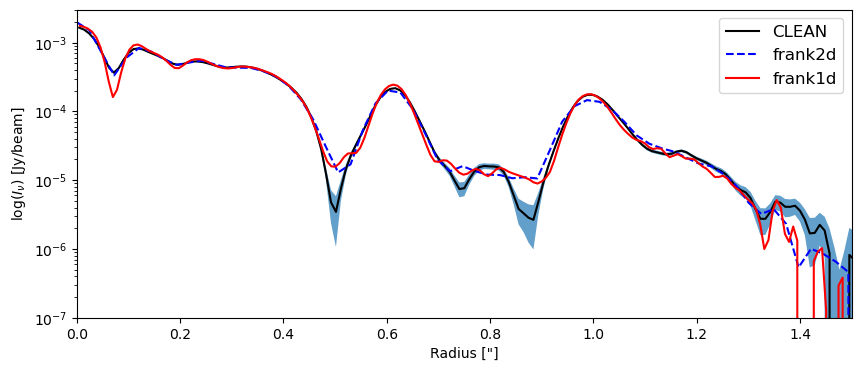

In [21]:
for i in range(len(frank2d_objects)):
    frank2d = frank2d_objects[i]
    Plot_ = Plot(frank2d)
    
    Plot_.set_f1d_solution(sol_f1d)
    Plot_.set_fits_file(fits_file)

    Plot_.intensity_profile(
    clean = True, frank1d = True,
    resol_f2d = 0.023, resol_f1d = 0.0147,
    x_lims = (0, 1.5), y_lims = (1e-7, 3e-3)
    )

In [28]:
frank2d_dicts = []
for i in range(len(frank2d_objects)):
    frank2d = frank2d_objects[i]
    dict_frank2d = {
        'visibility_model': frank2d.visibility_model,
        'intensity_model': frank2d.intensity_model,
        'u_grid': frank2d.u_grid,
        'v_grid': frank2d.v_grid,
        'x_grid': frank2d.x_grid*rad_to_arcsec,
        'y_grid': frank2d.y_grid*rad_to_arcsec,
    }
    frank2d_dicts.append(dict_frank2d)

## Save the models

In [ ]:
import pickle
frank2d_dicts = []
for i in range(len(frank2d_objects)):
    frank2d = frank2d_objects[i]
    
    with open("f2d_rout" + str(r_outs_name[i])+".pkl", "wb") as file:
        pickle.dump(dict_frank2d, file)

## Load the models

In [26]:
import pickle

frank2d_dicts = []
for i in r_outs_name:
    with open("../results/rout/f2d_rout" + str(i)+".pkl", 'rb') as f:
        obj = pickle.load(f)
        frank2d_dicts.append(obj)

In [28]:
for i in range(len(frank2d_dicts)):
    dict_frank2d = frank2d_dicts[i]
    x = dict_frank2d['x_grid']
    y = dict_frank2d['y_grid']
    I = dict_frank2d['intensity_model']

## Plot them all

In [29]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]

def calculate_resolution(clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [30]:
from frank.utilities import convolve_profile
from gofish import imagecube
from astropy.io import fits

# TODO: add option to change figsize.
inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

cube_1mm = imagecube(fits_file)
x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)

fits_image = fits.open(fits_file)
header = fits_image[0].header
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

resol_f2d = 0.023
resol_f1d = 0.0147

# Decide the beam to convolve with.
if resol_f2d > 0:
    print(f"FWHM for frank2d: {resol_f2d} arcsec")
    beam_for_f2d = calculate_resolution(clean_beam, resol_f2d)
else: 
    beam_for_f2d = clean_beam

if resol_f1d > 0:
    print(f"FWHM for frank1d: {resol_f1d} arcsec")
    beam_for_f1d = calculate_resolution(clean_beam, resol_f1d)
else:
    beam_for_f1d = clean_beam



	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


In [31]:
def get_profile(x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        weights_gridded = self._weights_input
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights_gridded, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights_gridded, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

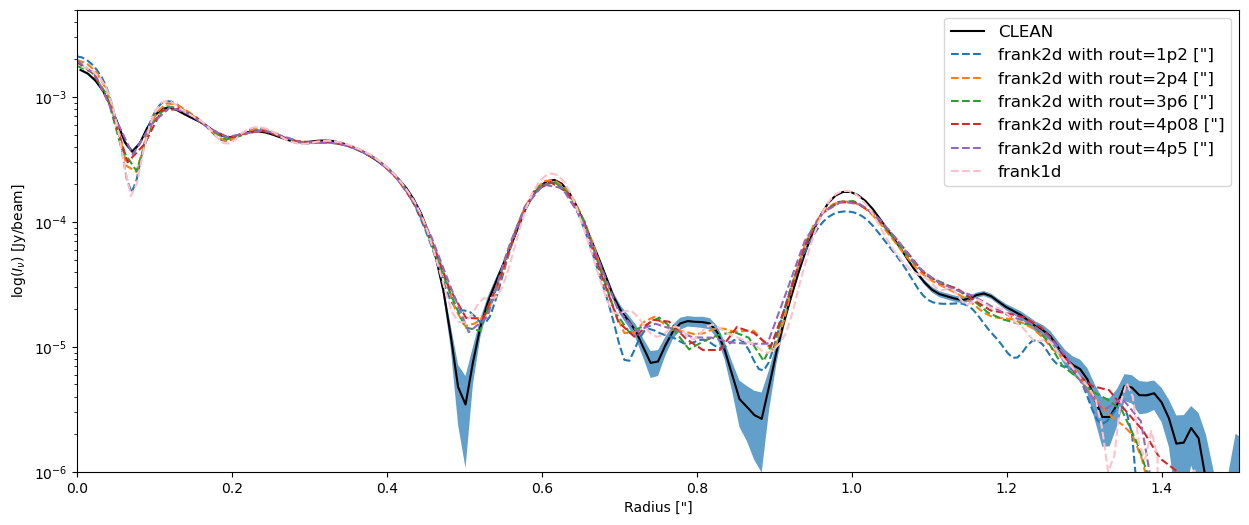

In [34]:
plt.figure(figsize=(15,6))

#  CLEAN --------------------------------------------------------------------
area = clean_area
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)

for i in range(len(frank2d_dicts)):
    # model
    frank2d_i = frank2d_dicts[i]
    
    x_model = frank2d_i["x_grid"]  # arcsec
    y_model = frank2d_i["y_grid"]  # arcsec
    x_model_1d = x_model.reshape(N, N)[0,:]
    y_model_1d = y_model.reshape(N, N)[:,0]
    I = frank2d_i["intensity_model"]

    # deproject
    x_model, y_model = geom.deproject_xy(x_model, y_model)
    x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

    # collocation points for the plot.
    r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
    bins = 300
    r = np.linspace(r.min(), r.max(), bins)
    edges_ = edges(r)

    r_model_1d, I_model_1d = get_profile(x_model, y_model, I, bins = edges_)
    I_model_1d = np.nan_to_num(I_model_1d, nan=0)

    # frank2D -------------------------------------------------------------------
    I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
    I_model_1d_convolved *= area # Jy/beam
    plt.plot(r_model_1d, I_model_1d_convolved,ls ='--',
             label = r'frank2d with rout=' + str(r_outs_name[i]) + ' ["]')


# frank1D ---------------------------------------------------------------
r_f1d = sol_f1d.r
I_f1d = sol_f1d.mean
I_f1d_convolved = convolve_profile(r_f1d, I_f1d, inc, pa, beam_for_f1d)
I_f1d_convolved *= area # Jy/beam
plt.plot(r_f1d, I_f1d_convolved, ls = '--', color = "pink", label = r'frank1d')
        

plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
x_lims = (0, 1.5)
y_lims = (1e-6, 5e-3)
plt.ylim(y_lims)
plt.xlim(x_lims)
plt.show()
